2025-04-03 22:12:28: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-04-03 22:12:28: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-04-03 22:12:28: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2025-04-03 22:12:28: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.
2025-04-03 22:12:28: oggm.cfg: WARNING: adding an unknown parameter `store_fl_diagnostics`:`True` to PARAMS.
2025-04-03 22:12:28: oggm.workflow: init_glacier_directories from prepro level 5 on 1 glaciers.
2025-04-03 22:12:29: oggm.workflow: Execute entity task gdir_from_prepro on 1 glaciers


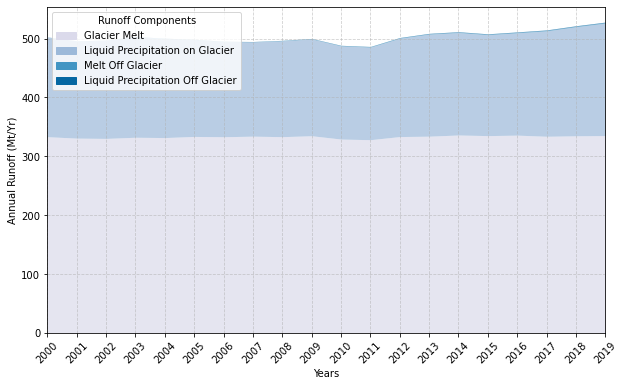

Yearly Runoff in 2000 (Megatonnes/Yr):
melt_on_glacier: 320.8042
liq_prcp_on_glacier: 163.1493
melt_off_glacier: 0.0438
liq_prcp_off_glacier: 0.0438

Total Runoff in 2000: 484.0411 Megatonnes

Yearly Runoff in 2019 (Megatonnes/Yr):
melt_on_glacier: 351.2970
liq_prcp_on_glacier: 186.5406
melt_off_glacier: 1.0839
liq_prcp_off_glacier: 1.2148

Total Runoff in 2019: 540.1363 Megatonnes


<Figure size 432x288 with 0 Axes>

In [1]:


import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import oggm.cfg as cfg
from oggm import utils, workflow, tasks

# Initialize OGGM and set up the default run parameters
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir('OGGM_historical_run', reset=True)
cfg.PARAMS['min_ice_thick_for_length'] = 1
cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['store_fl_diagnostics'] = True  # Important for hydrological outputs

# Define the glacier ID
rgi_id = 'RGI60-06.00291'

# Get the pre-processed glacier directories
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.4/L3-L5_files/CRU/elev_bands/qc3/pcp2.5/no_match'
gdirs = workflow.init_glacier_directories([rgi_id], from_prepro_level=5, prepro_border=80, prepro_base_url=base_url)

# Perform the historical run using actual climate data and hydrological output with fixed geometry spinup
file_id = '_hist_hydro'
tasks.run_with_hydro(gdirs[0], 
                     run_task=tasks.run_from_climate_data,
                     ys=2000, 
                     ye=2020,
                     store_monthly_hydro=True, 
                     output_filesuffix=file_id)

# Load glacier dataset with hydrological diagnostics
def load_glacier_dataset(gdirs):
    with xr.open_dataset(gdirs[0].get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
        return ds.isel(time=slice(0, -1)).load() 

# Function to plot glacier runoff
def plot_glacier_runoff(gdirs):
    # Load results
    ds = load_glacier_dataset(gdirs)
    
    # Runoff variables to plot
    runoff_vars = ['melt_on_glacier', 'liq_prcp_on_glacier', 'melt_off_glacier', 'liq_prcp_off_glacier']

    # Extract and process runoff data
    df_annual = ds[runoff_vars].to_dataframe() * 1e-9  # Convert to megatonnes
    df_annual = df_annual.reindex(np.arange(2000, 2020))  # Ensure data includes 2000
    df_runoff = df_annual.rolling(12, center=True, min_periods=1).mean()  # Smooth data

    # Create stacked area plot
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = sns.color_palette("PuBu", n_colors=len(runoff_vars)) 
    df_runoff.plot.area(ax=ax, color=colors, alpha=0.7, linewidth=0)

    # Set labels and x,y axis
    ax.set_xlabel('Years')
    ax.set_ylabel('Annual Runoff (Mt/Yr)')
    ax.set_xlim(2000, 2019)
    ax.set_xticks(np.arange(2000, 2020, 1))
    ax.set_xticklabels(np.arange(2000, 2020, 1).astype(int), rotation=45)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add legend manually
    legend_patches = [
        Patch(color=colors[0], label='Glacier Melt'),
        Patch(color=colors[1], label='Liquid Precipitation on Glacier'),
        Patch(color=colors[2], label='Melt Off Glacier'),
        Patch(color=colors[3], label='Liquid Precipitation Off Glacier')
    ]
    ax.legend(handles=legend_patches, title='Runoff Components', loc='upper left')
    
    # Save plots in different formats
    plt.show()
    plt.savefig('figureout/Runoff_CRU_20002019.png', dpi=300, bbox_inches='tight')
    

plot_glacier_runoff(gdirs)

# Fetch runoff and their components at the initial and final years
def get_yearly_runoff(gdirs):  
    # Load results  
    with xr.open_dataset(gdirs[0].get_filepath('model_diagnostics', filesuffix=file_id)) as ds:  
        historical_results = ds.isel(time=slice(0, -1)).load()  

    # Runoff variables  
    runoff_vars = ['melt_on_glacier', 'liq_prcp_on_glacier', 'melt_off_glacier', 'liq_prcp_off_glacier']  

    # Extract and process runoff data  
    df_annual = historical_results[runoff_vars].to_dataframe() * 1e-9  # Convert to megatonnes  
    df_annual = df_annual.reindex(np.arange(2000, 2020))  # Ensure we start from 2000

    # Get the initial and final years  
    initial_year = df_annual.index.min()
    final_year = df_annual.index.max()

    # Print initial year runoff values  
    print(f"Yearly Runoff in {initial_year} (Megatonnes/Yr):")  
    initial_runoff_values = df_annual.loc[initial_year, runoff_vars].to_dict()  
    for var, value in initial_runoff_values.items():
        print(f"{var}: {value:.4f}")  
    total_initial_runoff = sum(initial_runoff_values.values())  
    print(f"\nTotal Runoff in {initial_year}: {total_initial_runoff:.4f} Megatonnes\n")  

    # Print final year runoff values  
    print(f"Yearly Runoff in {final_year} (Megatonnes/Yr):")  
    final_runoff_values = df_annual.loc[final_year, runoff_vars].to_dict()  
    for var, value in final_runoff_values.items():
        print(f"{var}: {value:.4f}")  
    total_final_runoff = sum(final_runoff_values.values())  
    print(f"\nTotal Runoff in {final_year}: {total_final_runoff:.4f} Megatonnes")  

# Call the function to get yearly runoff
get_yearly_runoff(gdirs)

In [2]:
def print_monthly_liquid_precipitation(gdirs):
        ds = load_glacier_dataset(gdirs)
    
        monthly_data = ds['liq_prcp_on_glacier_monthly'].values * 1e-9  # Convert to megatonnes
        
        # Print detailed monthly volumes
        print("Monthly Glacier Liquid Precipitation Volumes (Megatonnes):")
        
        # Track valid months
        valid_months = []
        
        # Iterate through years and months
        for year_idx, year in enumerate(range(2000, 2021)):
            for month_idx in range(12):
                volume = monthly_data[year_idx, month_idx]
                date_str = f"{year}-{month_idx+1:02d}"
                print(f"{date_str}: {volume:.4f}")
                valid_months.append((date_str, volume))
        
        # Additional analysis
        valid_volumes = [vol for _, vol in valid_months]
        print("\nLiquid Precipitation Volume Statistics:")
        print(f"Total Months Analyzed: {len(valid_months)}")
        print(f"Mean Monthly Volume: {np.mean(valid_volumes):.4f} Megatonnes")
        print(f"Minimum Monthly Volume: {np.min(valid_volumes):.4f} Megatonnes")
        print(f"Maximum Monthly Volume: {np.max(valid_volumes):.4f} Megatonnes")

# Use the previously defined gdirs from the original script
print_monthly_liquid_precipitation(gdirs)

Monthly Glacier Liquid Precipitation Volumes (Megatonnes):
2000-01: 24.6309
2000-02: 0.0939
2000-03: 0.0000
2000-04: 0.0000
2000-05: 0.0000
2000-06: 0.0000
2000-07: 0.2126
2000-08: 36.8891
2000-09: 19.0281
2000-10: 26.1024
2000-11: 21.3503
2000-12: 34.8421
2001-01: 9.4517
2001-02: 0.0000
2001-03: 0.0000
2001-04: 0.1707
2001-05: 0.0000
2001-06: 0.0000
2001-07: 2.5524
2001-08: 37.7657
2001-09: 14.7040
2001-10: 37.5872
2001-11: 21.3246
2001-12: 35.3748
2002-01: 24.5347
2002-02: 0.0064
2002-03: 0.7787
2002-04: 0.0063
2002-05: 0.0000
2002-06: 0.0000
2002-07: 11.4752
2002-08: 16.9770
2002-09: 11.6366
2002-10: 23.2025
2002-11: 39.2926
2002-12: 47.0301
2003-01: 10.0801
2003-02: 7.2591
2003-03: 9.3386
2003-04: 0.0001
2003-05: 1.6639
2003-06: 7.8963
2003-07: 25.2483
2003-08: 10.8764
2003-09: 22.7845
2003-10: 36.3360
2003-11: 25.9219
2003-12: 46.0198
2004-01: 12.7026
2004-02: 0.9565
2004-03: 0.0000
2004-04: 0.0000
2004-05: 0.0000
2004-06: 11.2336
2004-07: 21.6854
2004-08: 32.7274
2004-09: 23.0504

IndexError: index 20 is out of bounds for axis 0 with size 20

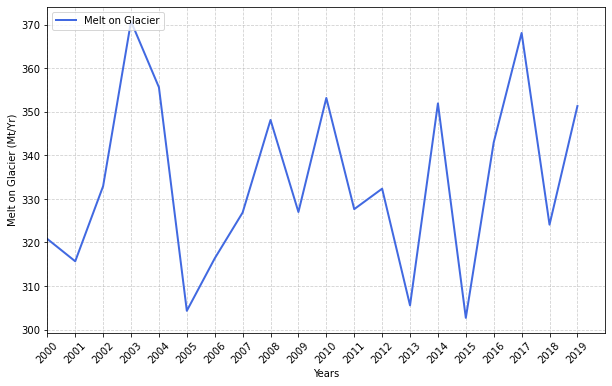

In [3]:
# Function to analyze and plot melt_on_glacier runoff (without rolling mean)
def plot_melt_on_glacier(gdirs):
    # Load the dataset
    ds = load_glacier_dataset(gdirs)
    
    # Extract and process melt_on_glacier data
    melt_on_glacier_data = ds['melt_on_glacier'].to_series() * 1e-9  # Convert to megatonnes
    
    # Create a plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(melt_on_glacier_data.index, melt_on_glacier_data.values, label='Melt on Glacier', color='royalblue', lw=2)

    # Set labels and title
    ax.set_xlabel('Years')
    ax.set_ylabel('Melt on Glacier (Mt/Yr)')
    
    # Set x-axis limits and ticks
    ax.set_xlim(2000, 2020)
    ax.set_xticks(np.arange(2000, 2020, 1))  # Set ticks for each year
    ax.set_xticklabels(np.arange(2000, 2020, 1).astype(int), rotation=45)

    # Add a grid
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add legend 
    ax.legend(['Melt on Glacier'], loc='upper left')

    # Save and show the plot
    plt.savefig('figureout/Melt_on_Glacier_CRU_20002019.png', dpi=300, bbox_inches='tight')
    plt.show()

# Call the function to plot melt on glacier runoff
plot_melt_on_glacier(gdirs)

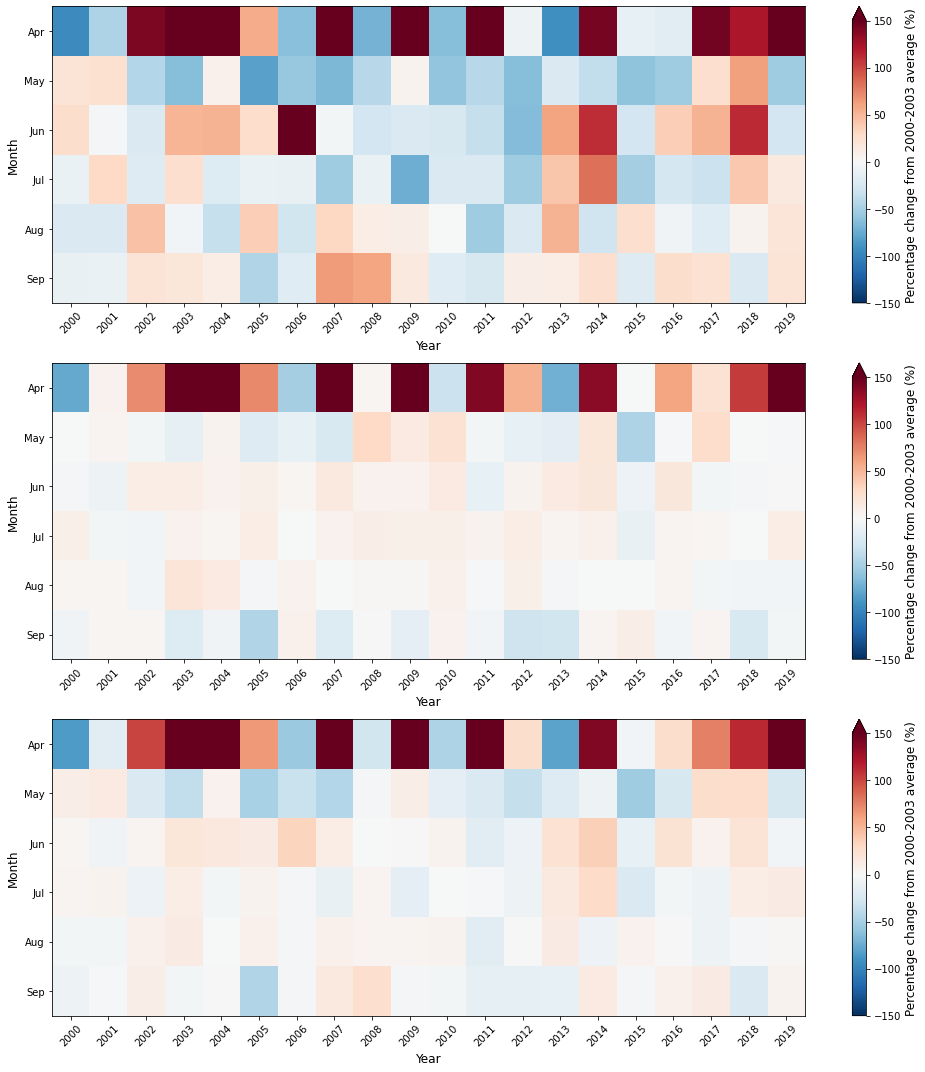

In [ ]:
# Adjust for hydrological months
ds = load_glacier_dataset(gdirs)
ds_roll = ds.roll(month_2d=ds['calendar_month_2d'].data[0]-1, roll_coords=True)
ds_roll['month_2d'] = ds_roll['calendar_month_2d']

# Create 3 subplots (now including melt)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 15))


def plot_april_september_change(ax, data, title):
    
    """Plot percentage changes with complete year coverage"""  
     # Calculate baseline as average of 2000-2003
    baseline = data.sel(time=slice('2000', '2003')).mean(dim='time')
    percent_change = ((data - baseline) / baseline) * 100
    
    # Select April-September months 
    summer_data = percent_change.isel(month_2d=[8, 7, 6, 5, 4, 3])
    summer_data = summer_data.assign_coords(month_2d=np.arange(6))  # Reindex to 0-5
    
    # Plot cmap
    cmap = plt.cm.RdBu_r
    im = summer_data.T.plot(ax=ax, cmap=cmap, center=0, 
                          add_colorbar=True,
                          vmin=-150, vmax=150,
                          cbar_kwargs={'label': 'Percentage change from 2000-2003 average (%)'})
    
    # Formatting
    cbar = im.colorbar
    cbar.ax.set_ylabel('Percentage change from 2000-2003 average (%)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Month', fontsize=12)
    ax.set_yticks(range(6))
    ax.set_yticklabels(['Sep', 'Aug', 'Jul', 'Jun', 'May', 'Apr'], fontsize=10)  # Reversed labels
    ax.set_xticks(np.arange(2000, 2020, 1))
    ax.set_xticklabels(np.arange(2000, 2020, 1).astype(int), rotation=45)

# Plot precipitation 
monthly_precip = ds_roll['liq_prcp_on_glacier_monthly'] * 1e-9
plot_april_september_change(ax1, monthly_precip, '')

# Plot glacier melt 
monthly_melt = ds_roll['melt_on_glacier_monthly'] * 1e-9
plot_april_september_change(ax2, monthly_melt, '')

# Plot total runoff
total_runoff = (ds_roll['melt_on_glacier_monthly'] + ds_roll['liq_prcp_on_glacier_monthly']) * 1e-9
plot_april_september_change(ax3, total_runoff, '')

plt.tight_layout()
plt.savefig('figureout/April_September_Percentage_Change_CRU.png', dpi=300, bbox_inches='tight')
plt.show()

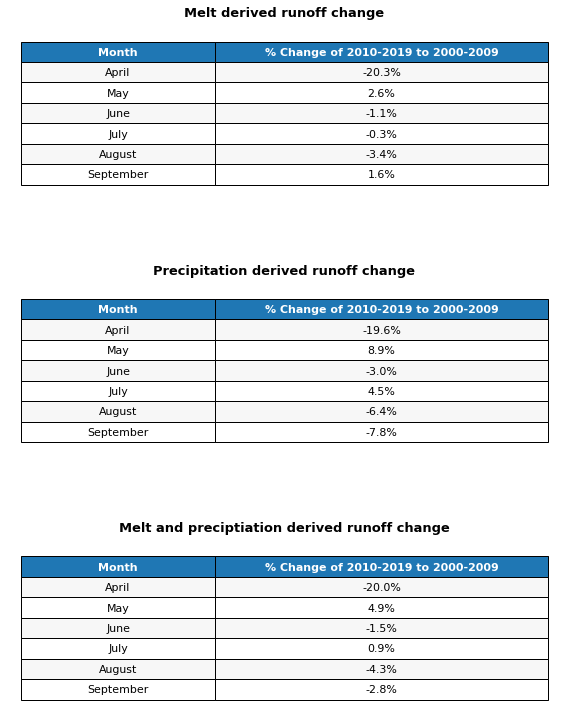

In [ ]:
# Load the dataset and adjust for hydrological months
ds = load_glacier_dataset(gdirs)
ds_roll = ds.roll(month_2d=ds['calendar_month_2d'].data[0]-1, roll_coords=True)
ds_roll['month_2d'] = ds_roll['calendar_month_2d']

# Modified percentage change calculation to handle both strings and DataArrays
def calculate_percentage_change(dataset, variable):
 
    # Handle both string variable names and DataArrays
    if isinstance(variable, str):
        data = dataset[variable]
    else:
        data = variable
    
    # Calculate 2000-2009 mean
    baseline = data.sel(time=slice('2000', '2009')).mean(dim='time')
    
    # Calculate 2010-2019 mean 
    recent = data.sel(time=slice('2010', '2019')).mean(dim='time')
    
    # Calculate percentage change
    percent_change = ((recent - baseline) / baseline) * 100
    
    return percent_change

# Table creation and formatting (summer months only)
def create_percentage_table(ax, percent_change, title):
    # Using month_2d coordinates from rolled dataset
    summer_months = [3, 4, 5, 6, 7, 8]  # April to September in rolled data
    month_names = ['April', 'May', 'June', 'July', 'August', 'September']
    values = percent_change.values[summer_months]

    # Table data
    table_data = [
        ['Month', '% Change of 2010-2019 to 2000-2009'],
        *[[month, f'{value:.1f}%'] for month, value in zip(month_names, values)]
    ]

    # Create table
    table = ax.table(cellText=table_data, loc='center', cellLoc='center',
                    colWidths=[0.35, 0.6])

    # Style table
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.8)

    # Header styling
    for i in range(2):
        table[(0, i)].set_facecolor('#1f77b4')  # Blue header
        table[(0, i)].set_text_props(color='white', weight='bold')

    # Alternate row colors
    for row in range(1, len(table_data)):
        color = '#f7f7f7' if row % 2 == 1 else '#ffffff'
        for col in range(2):
            table[(row, col)].set_facecolor(color)

    # Add title
    ax.set_title(title, y=1.1, fontsize=13, fontweight='bold')
    ax.axis('off')

# Calculate changes using rolled dataset
runoff_change = calculate_percentage_change(ds_roll, 'melt_on_glacier_monthly')
precip_change = calculate_percentage_change(ds_roll, 'liq_prcp_on_glacier_monthly')

# Calculate total runoff properly by summing components first
total_runoff = ds_roll['melt_on_glacier_monthly'] + ds_roll['liq_prcp_on_glacier_monthly']
total_change = calculate_percentage_change(ds_roll, total_runoff)

# Create figure
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10))

# Plot tables
create_percentage_table(ax1, runoff_change, 'Melt derived runoff change')
create_percentage_table(ax2, precip_change, 'Precipitation derived runoff change')
create_percentage_table(ax3, total_change, 'Melt and preciptiation derived runoff change')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.7)  # Space between tables

# Save output
plt.savefig('figureout/Summer_Percentage_Changes_CRU.png', 
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()